# fit cell and gene density function and try to quantify the gradient from there?

In [1]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import anndata
import sys 
sys.path.append('/home/shuonan.chen/scratch_shuonan/code/LCNE_transcriptomics/code/')
import plotting,utils, processing
allmeshes = utils.load_mesh()
import squidpy as sq
import scanpy as sc

import trimesh
mesh_LC = trimesh.load_mesh("/allen/aind/scratch/shuonan.chen/scripts/Pons_MERFISH/mesh/LC_ccf_v1_250102 2.obj")

/allen/aind/scratch/shuonan.chen/conda_envs/torch_on_gpu_py310/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/allen/aind/scratch/shuonan.chen/conda_envs/torch_on_gpu_py310/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)


In [2]:
adata_foo = sc.read_h5ad("/home/shuonan.chen/scratch_shuonan//LC_scRNAseq/conversion_files/snRNAseq_LCNE_BN_new.h5ad")
adata_sc = anndata.AnnData(adata_foo.layers['BN'])
adata_sc.obs = adata_foo.obs.copy()
adata_sc.obsm = adata_foo.obsm.copy()
adata_sc.var = adata_foo.var.copy()

filename = '/allen/aind/scratch/shuonan.chen/code/pons_merfish_pipeline/processing/data/adata_mer_subset_2_6k.h5ad'
adata_mer = sc.read_h5ad(filename)
var_names = adata_mer.var_names.intersection(adata_sc.var_names)
adata_mer = adata_mer[:,var_names]  # 314 genes 
adata_mer = adata_mer[adata_mer.obs['leiden']!='5',:]
adata_mer.shape
sc.pp.normalize_total(adata_mer, 1e4)

/scratch/fast/1322177/ipykernel_4009484/2952035988.py:13: FutureWarning: The specified parameters ('target_sum',) are no longer positional. Please specify them like `target_sum=10000.0`
  sc.pp.normalize_total(adata_mer, 1e4)
/allen/aind/scratch/shuonan.chen/conda_envs/torch_on_gpu_py310/lib/python3.10/site-packages/scanpy/preprocessing/_normalization.py:207: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


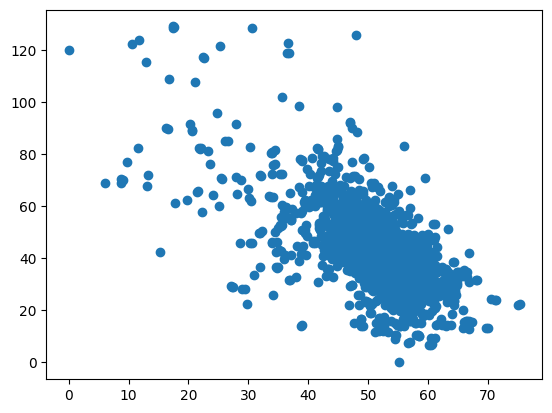

In [3]:
coords  = adata_mer.obsm['spatial'].copy()
coords = processing.get_hemi(coords)
coords -= np.min(coords,0)
plt.scatter(coords[:,2],coords[:,1]) # just to make sure only one side is left 

# kernel density estiamte of cells. 

In [4]:
from scipy.stats import gaussian_kde

In [5]:
data_for_kde = coords.T  # s(3, 4895)
kde = gaussian_kde(data_for_kde)
dens3d = kde(coords.T)  # density estimate at each input points 

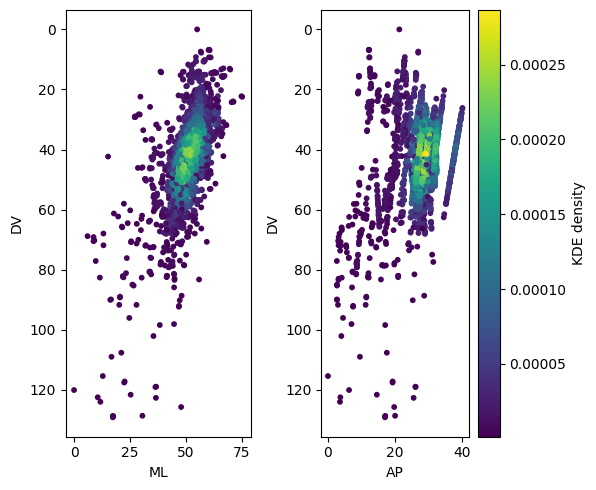

In [6]:
plt.figure(figsize=(6, 5))
plt.subplot(1,2,1)
sc = plt.scatter(coords[:, 2], coords[:, 1], 
    c=dens3d,s=10,alpha = 1, cmap="viridis")
plt.xlabel("ML")
plt.ylabel("DV")
plt.gca().invert_yaxis()

plt.subplot(1,2,2)
sc = plt.scatter(coords[:, 0], coords[:, 1], 
    c=dens3d,s=10,alpha = 1, cmap="viridis")
plt.xlabel("AP")
plt.ylabel("DV")
plt.gca().invert_yaxis()
plt.colorbar(sc, label="KDE density")
plt.tight_layout()
plt.show()

In [7]:

np.sum(dens3d)

np.float64(0.2254906613613457)

# get the gradient

In [8]:
np.ptp(coords,0)

array([ 40.18583288, 129.13042889,  75.24841443])

In [9]:
# Define a 3D grid
x_min, x_max = coords[:, 0].min(), coords[:, 0].max()
y_min, y_max = coords[:, 1].min(), coords[:, 1].max()
z_min, z_max = coords[:, 2].min(), coords[:, 2].max()

# N_grid = 60
# x_lin = np.linspace(x_min, x_max, N_grid)
# y_lin = np.linspace(y_min, y_max, N_grid)
# z_lin = np.linspace(z_min, z_max, N_grid)

x_lin = np.arange(x_min, x_max, step =2)
y_lin = np.arange(y_min, y_max, step =2)
z_lin = np.arange(z_min, z_max, step =2)
N_grid = [len(x_lin),len(y_lin),len(z_lin)]

# Build a meshgrid: shapes will be (N_grid, N_grid, N_grid) each
Xg, Yg, Zg = np.meshgrid(x_lin, y_lin, z_lin, indexing='ij')
pts = np.vstack([Xg.ravel(), Yg.ravel(),Zg.ravel()]) 

In [10]:
Xg.shape, Yg.shape

((21, 65, 38), (21, 65, 38))

# KDE on the grid

In [12]:
N_grid

[21, 65, 38]

In [13]:
# fake points for evaluating KDE

D = kde(pts).reshape(Xg.shape)  

In [31]:
# confirm it sums up to one. 

step = 2
cell_vol = step**3  # = 8

# your D is shape (nx,ny,nz)
prob = D * cell_vol
print("Sum of density values:", D.sum())
print("Sum of discrete probabilities:", prob.sum())  # ≈ 1

Sum of density values: 0.12345278803148071
Sum of discrete probabilities: 0.9876223042518457


# partial derivatives

In [32]:
dx

np.float64(2.0)

In [33]:
dx = x_lin[1] - x_lin[0]
dy = y_lin[1] - y_lin[0]
dz = z_lin[1] - z_lin[0]

dD_dx, dD_dy, dD_dz = np.gradient(D, dx, dy, dz, edge_order=1)

Text(0.5, 0.98, 'dD/dy')

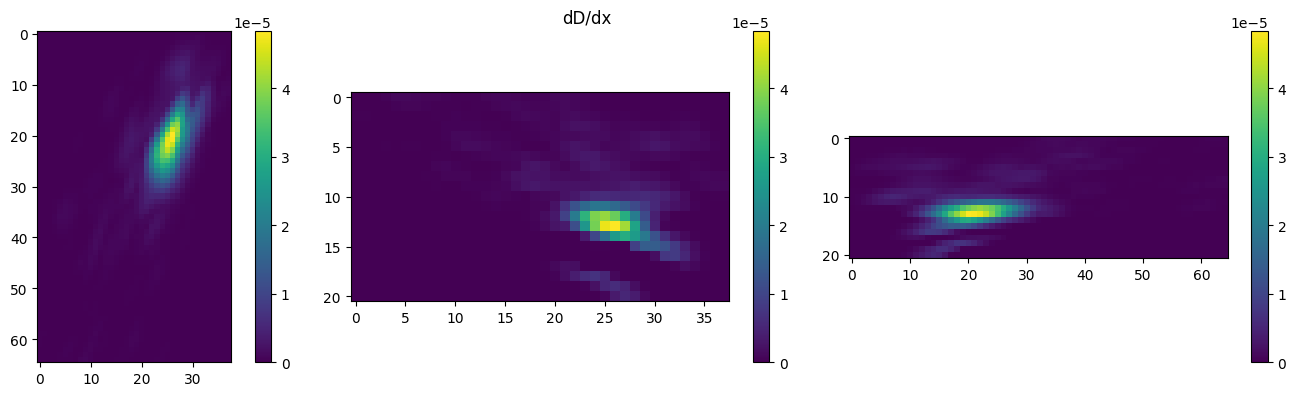

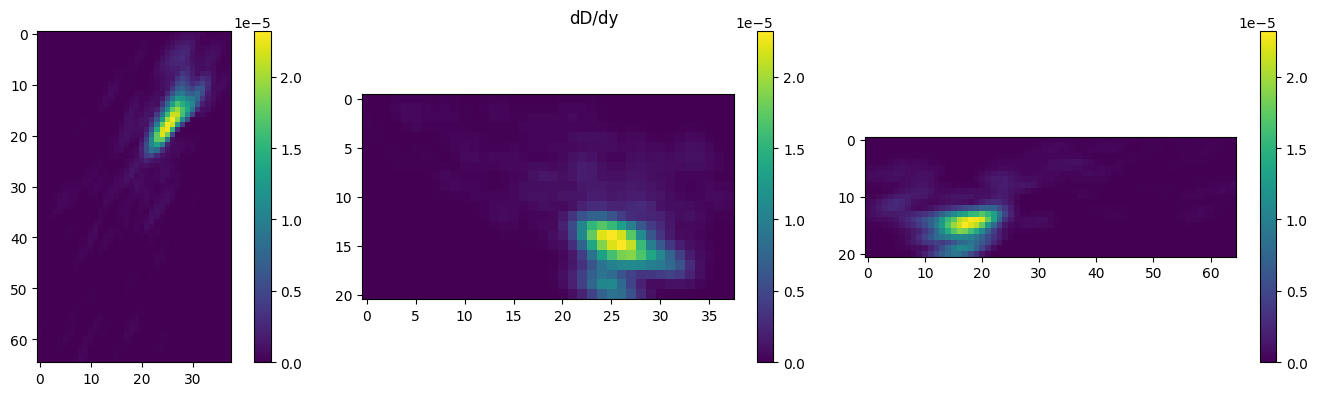

In [34]:
# plot the partial derivatives 

plt.figure(figsize = (15,4))
for i in range(3):
    plt.subplot(1,3,i+1)
    plt.imshow(np.max(dD_dx, i), aspect = 'equal')
    plt.colorbar()
plt.tight_layout()    
plt.suptitle('dD/dx')

plt.figure(figsize = (15,4))
for i in range(3):
    plt.subplot(1,3,i+1)
    plt.imshow(np.max(dD_dy, i), aspect = 'equal')
    plt.colorbar()
plt.tight_layout()    
plt.suptitle('dD/dy')

In [68]:
x_lin

array([ 0.,  2.,  4.,  6.,  8., 10., 12., 14., 16., 18., 20., 22., 24.,
       26., 28., 30., 32., 34., 36., 38., 40.])

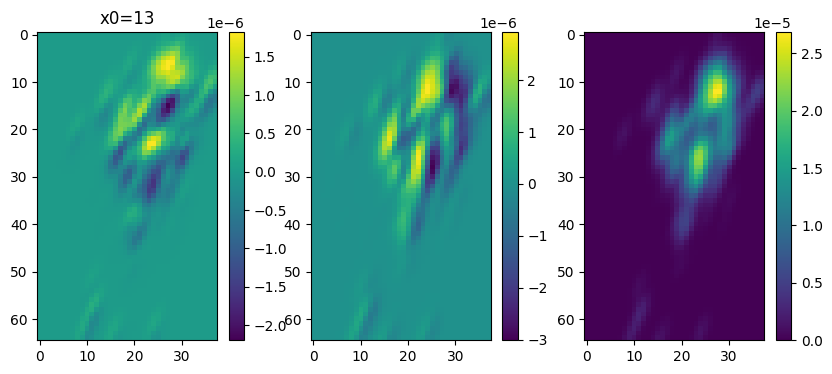

In [53]:
x0= np.argmax(np.max(dD_dx, (1,2)))
i0 = np.argmin(np.abs(x_lin - x0))
i0=10
x0 = x_lin[i0]


DY_slice = dD_dy[i0, :, :]  # shape (N_grid, N_grid)
DZ_slice = dD_dz[i0, :, :]

plt.figure(figsize = (10, 4))
plt.subplot(1,3,1);plt.imshow(DY_slice, aspect = 'equal');plt.colorbar()
plt.title(f'x0={x0}')
plt.subplot(1,3,2);plt.imshow(DZ_slice, aspect = 'equal');plt.colorbar()
plt.subplot(1,3,3);plt.imshow(D[i0], aspect = 'equal');plt.colorbar()

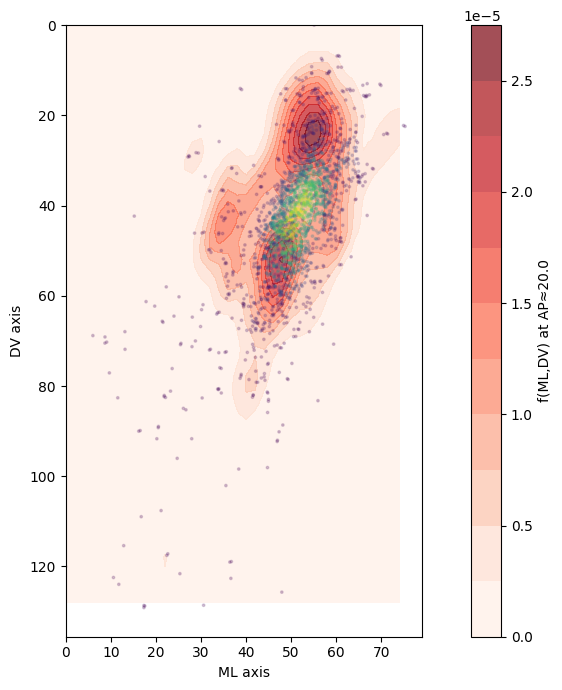

In [54]:

plt.figure(figsize=(10, 7))
plt.contourf(
    Zg[i0, :, :], Yg[i0, :, :], D[i0, :, :], 
    levels=10, cmap="Reds", alpha=0.7)
plt.colorbar(label="f(ML,DV) at AP≈{:.1f}".format(x_lin[i0]))
plt.gca().set_aspect('equal')
sc = plt.scatter(coords[:, 2], coords[:, 1], c=dens3d, s=3,alpha = .2, cmap="viridis")
plt.ylabel("DV axis")
plt.xlabel("ML axis")
# plt.title("Gradient field ∂f/∂z, ∂f/∂y at x≈{:.2f}".format(x_lin[i0]))
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


In [78]:
x_lin

array([ 0.,  2.,  4.,  6.,  8., 10., 12., 14., 16., 18., 20., 22., 24.,
       26., 28., 30., 32., 34., 36., 38., 40.])

In [90]:
len(x_lin)

21

array([ 0,  2,  4,  6,  8, 10, 12, 14, 16, 18, 20])

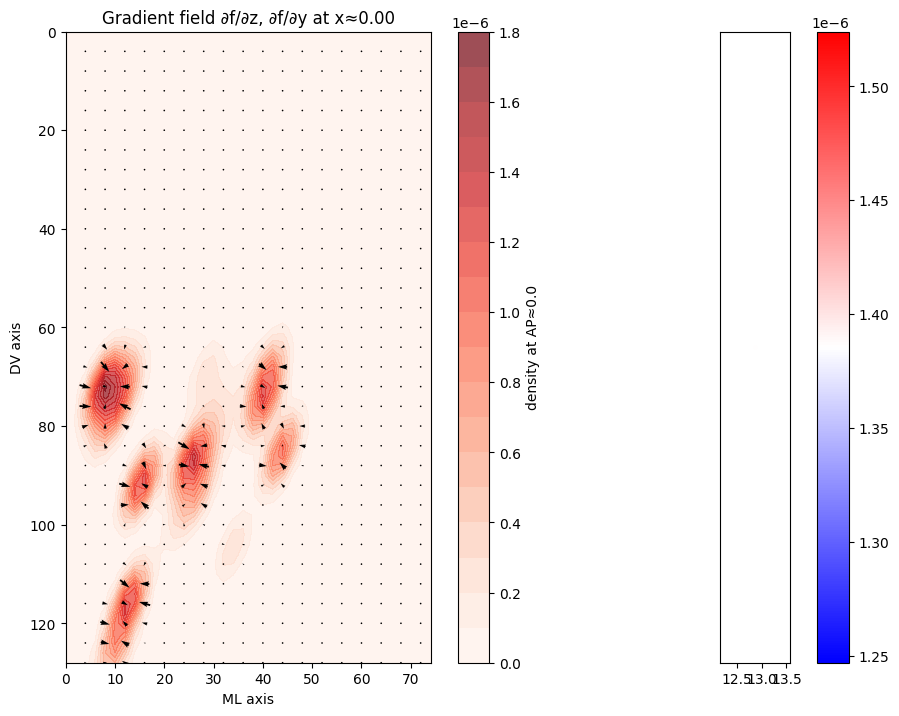

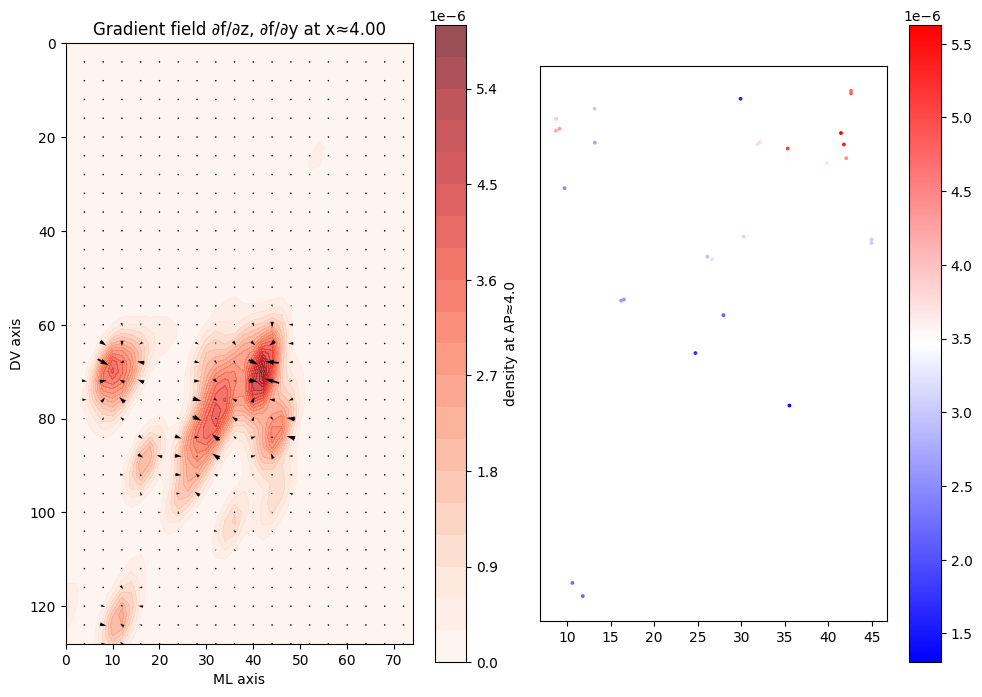

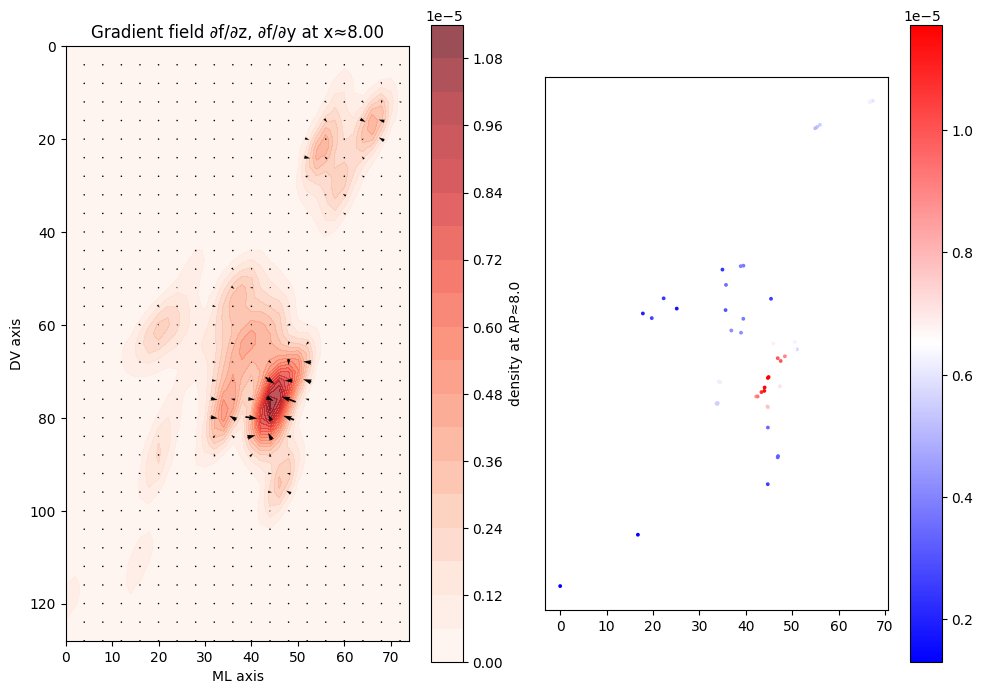

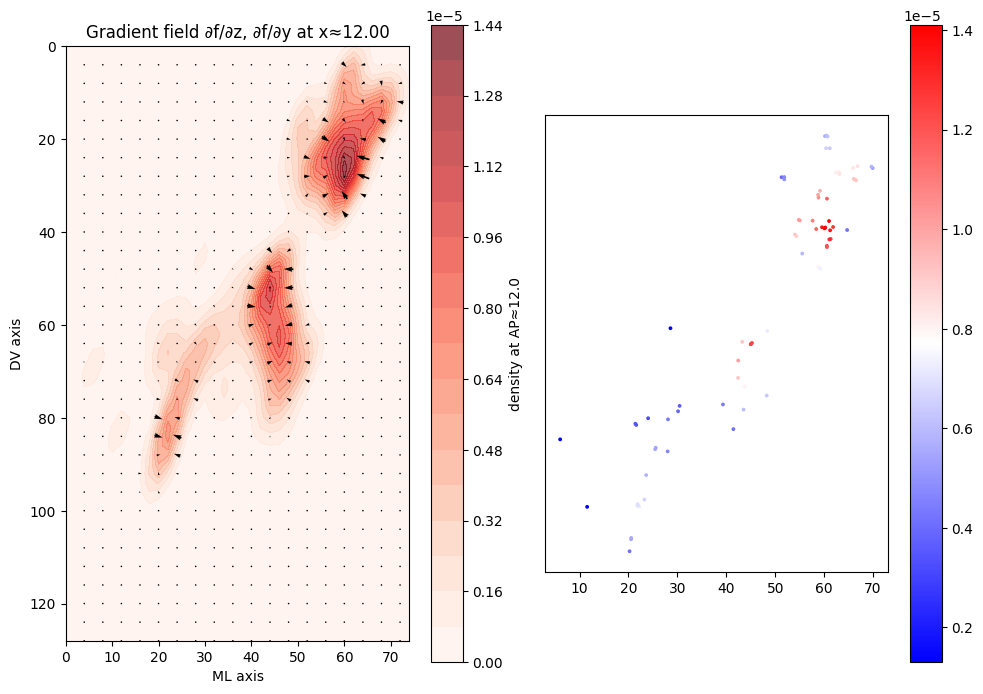

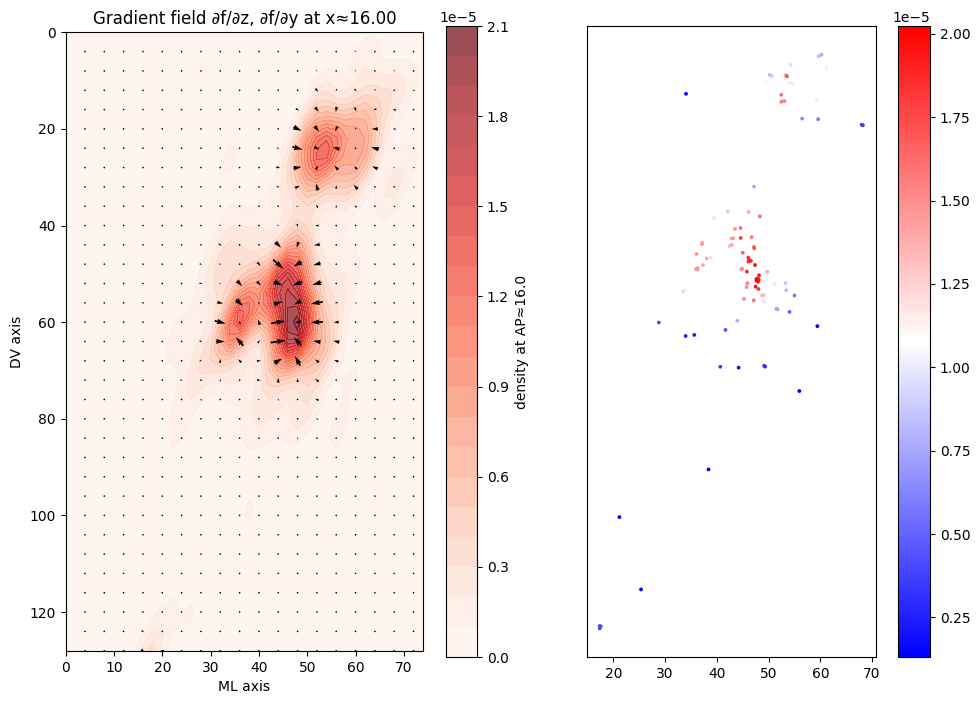

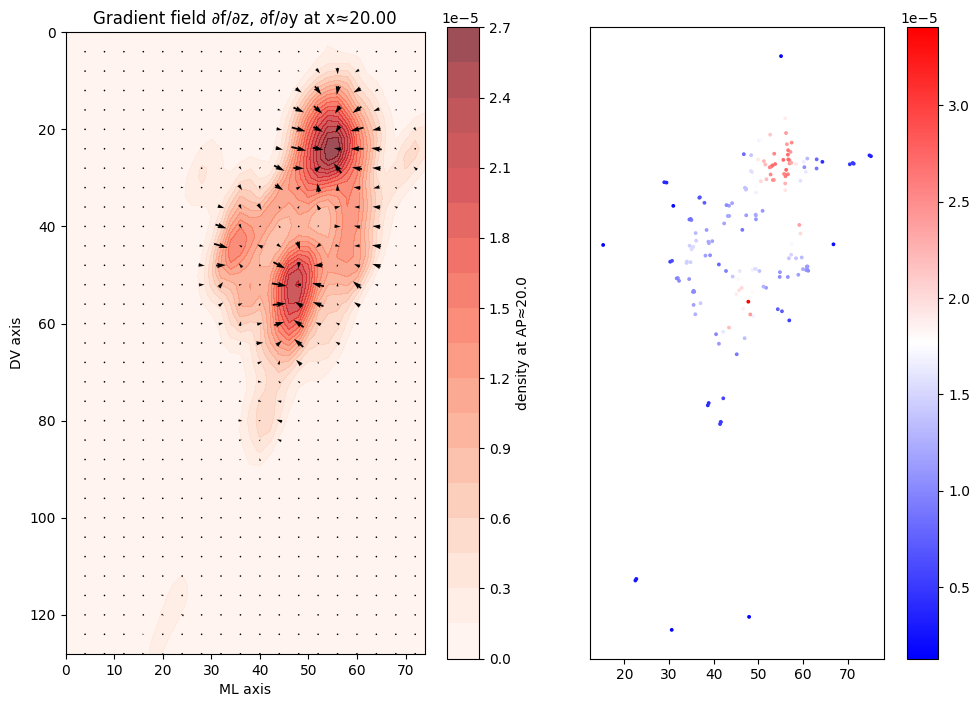

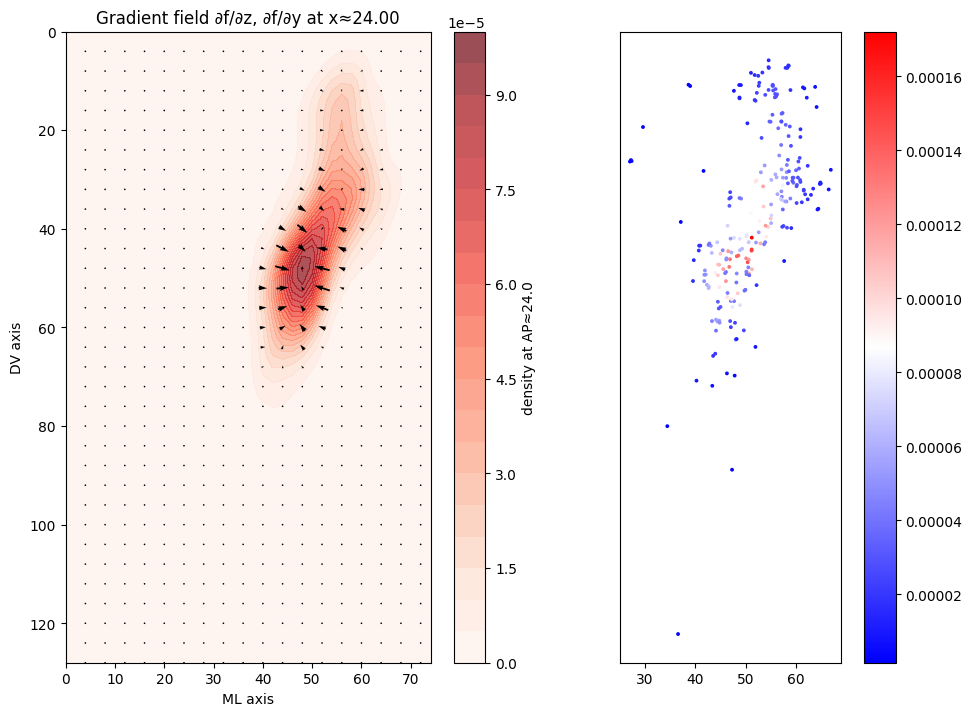

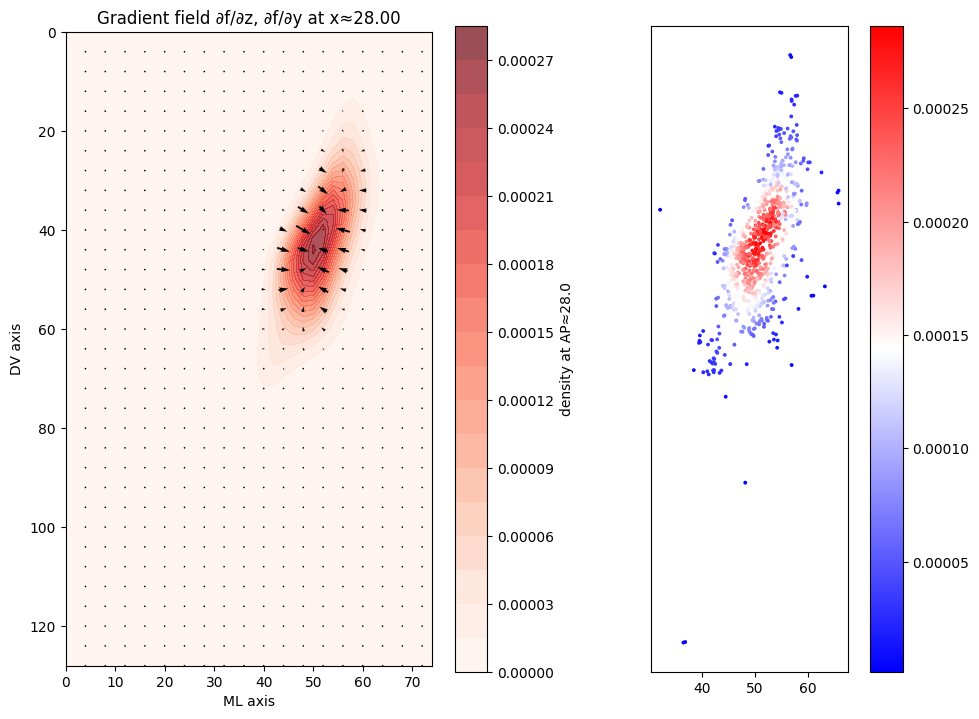

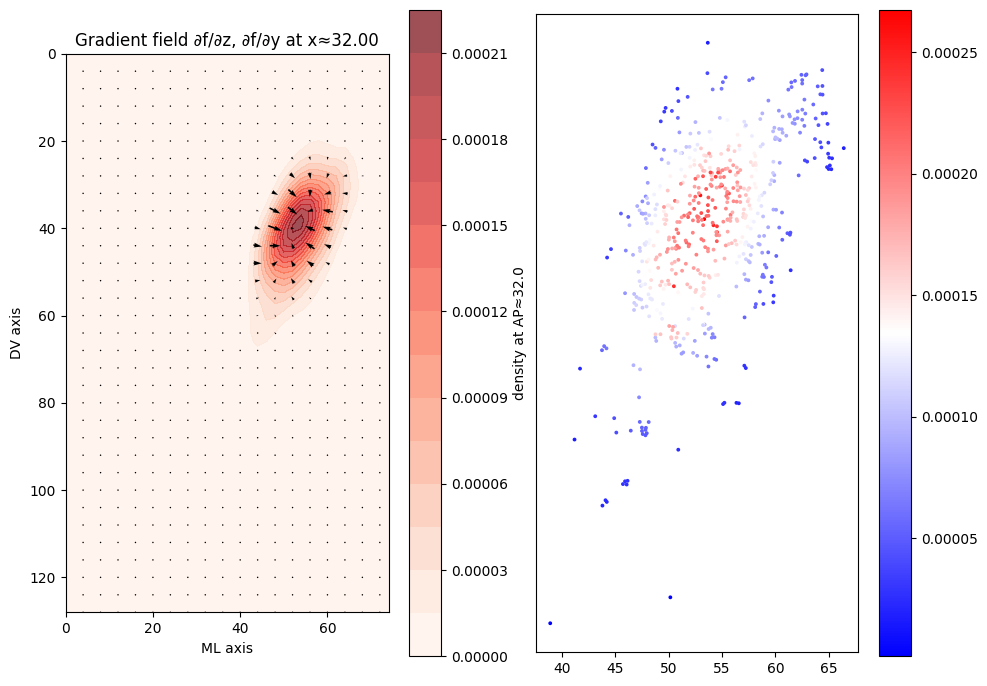

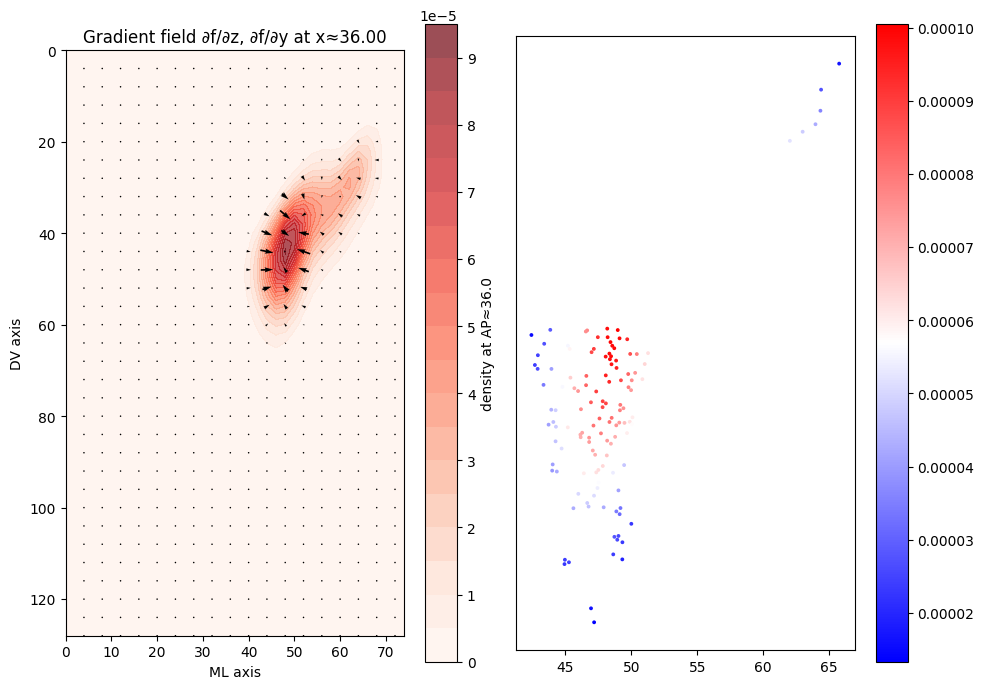

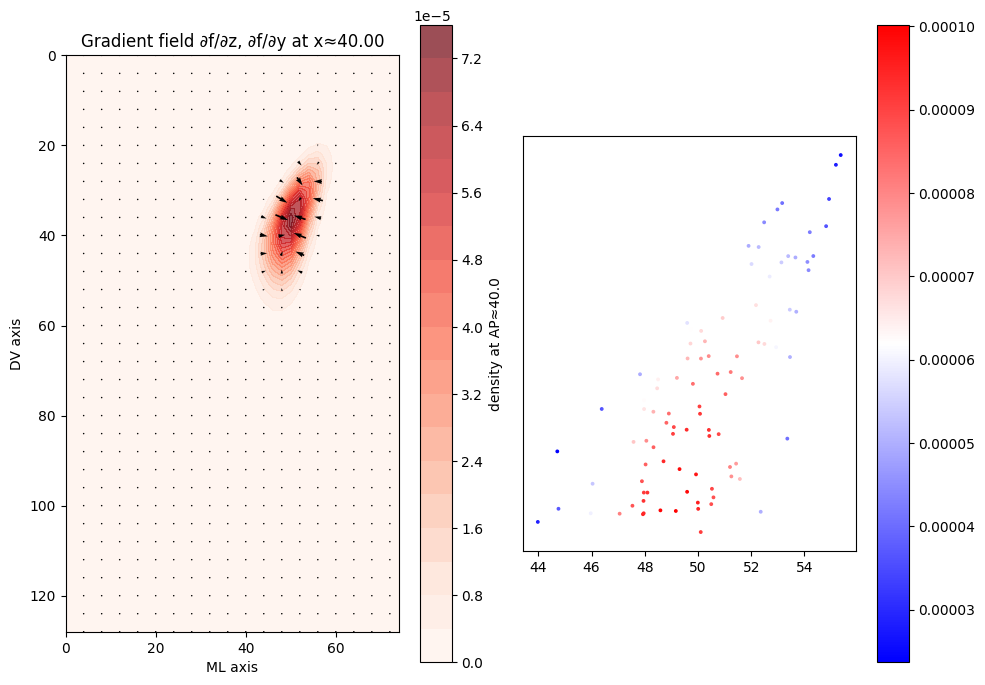

In [93]:
for i0 in np.arange(0,len(x_lin),2):
    x0 = x_lin[i0]
    plt.figure(figsize=(10, 7))
    plt.subplot(1,2,1)
    plt.contourf(
        Zg[i0, :, :], Yg[i0, :, :], D[i0, :, :], 
        levels=20, cmap="Reds", alpha=0.7)
    plt.colorbar(label="density at AP≈{:.1f}".format(x0))
    plt.gca().set_aspect('equal')
    DY_slice = dD_dy[i0, :, :]  # shape (N_grid, N_grid)
    DZ_slice = dD_dz[i0, :, :]

    mag = np.sqrt(DZ_slice**2 + DY_slice**2)
    max_mag = mag.max()
    step = 2
    Q = plt.quiver(
        Zg[i0,::step, ::step],     # X‐positions (ML)
        Yg[i0,::step, ::step],     # Y‐positions (DV)
        DZ_slice[::step, ::step],    # horizontal component = ∂f/∂z
        DY_slice[::step, ::step],    # vertical component   = ∂f/∂y
        color="k",
        pivot="mid",
        angles="xy",
        scale_units="xy",
        scale=max_mag * .3,   # 
        width=0.005            # a slightly thicker arrow‐shaft
    )
    plt.ylabel("DV axis")
    plt.xlabel("ML axis")
    plt.title("Gradient field ∂f/∂z, ∂f/∂y at x≈{:.2f}".format(x_lin[i0]))
    plt.gca().invert_yaxis()


    plt.subplot(1,2,2)
    point_range = 2
    spotid = np.abs(coords[:,0]-x0)<=point_range
    plt.scatter(coords[spotid,2],coords[spotid,1], c=dens3d[spotid], s=3,alpha = 1, cmap="bwr")
    plt.colorbar()
    plt.gca().set_aspect('equal')
    plt.gca().invert_yaxis()
    plt.gca().set_yticks([])
    plt.tight_layout()
    plt.show()


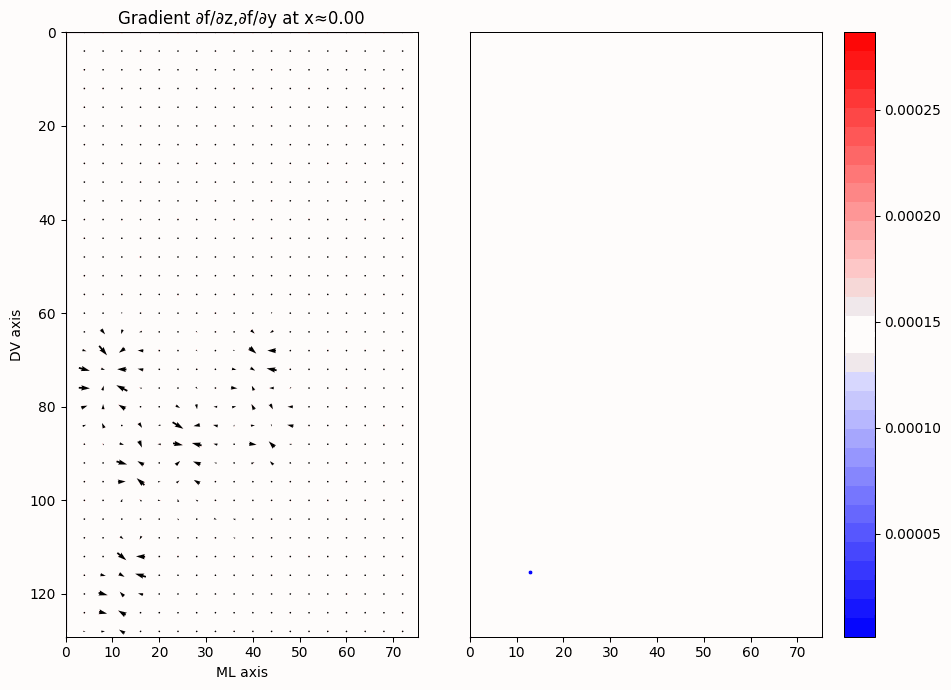

In [103]:
import numpy as np
import matplotlib.pyplot as plt
from generate_gif import savefig_PIL, gif_from_pngs  # adjust import path as needed
import IPython

# collect frames here
gif_frames = []

for i0 in np.arange(0, len(x_lin), 1):
    x0 = x_lin[i0]

    # ---- first subplot: density + gradient field ----
    plt.figure(figsize=(10, 7))
    plt.subplot(1, 2, 1)
    plt.contourf(
        Zg[i0], Yg[i0], D[i0],
        levels=20, 
        cmap="Reds", vmin = D.min(), 
        vmax = D.max(), alpha=0.7
    )
#     plt.colorbar(label=f"density at AP≈{x0:.1f}")
    plt.gca().set_aspect("equal")
    DY_slice = dD_dy[i0]
    DZ_slice = dD_dz[i0]

    mag = np.sqrt(DZ_slice**2 + DY_slice**2)
    step = 2
    plt.quiver(
        Zg[i0, ::step, ::step],
        Yg[i0, ::step, ::step],
        DZ_slice[::step, ::step],
        DY_slice[::step, ::step],
        pivot="mid", angles="xy",
        scale_units="xy", scale=mag.max() * 0.3,
        width=0.005, color="k"
    )
    plt.xlabel("ML axis")
    plt.ylabel("DV axis")
    plt.title(f"Gradient ∂f/∂z,∂f/∂y at x≈{x0:.2f}")
    plt.gca().invert_yaxis()
    plt.ylim(coords[:,1].max(),coords[:,1].min())
    plt.xlim(coords[:,2].min(),coords[:,2].max())

    # ---- second subplot: data scatter ----
    plt.subplot(1, 2, 2)
    spotid = np.abs(coords[:, 0] - x0) <= 2
    plt.scatter(
        coords[spotid, 2], coords[spotid, 1],
        c=dens3d[spotid], s=3, alpha=1, cmap="bwr",
        vmin = dens3d.min(), vmax = dens3d.max()
    )
    plt.colorbar()
    plt.gca().set_aspect("equal")
    plt.gca().invert_yaxis()
    plt.gca().set_yticks([])
    plt.ylim(coords[:,1].max(),coords[:,1].min())
    plt.xlim(coords[:,2].min(),coords[:,2].max())
    plt.tight_layout()

    # save this frame into memory, then close
    frame_bytes = savefig_PIL(format="png", bbox_inches="tight")
    gif_frames.append(frame_bytes)
    plt.close()

# build the gif (duration in ms per frame)
gif = gif_from_pngs(gif_frames, duration=250)

# display inline in a notebook
IPython.display.Image(gif)


# gene gradients
- interpolate gene expression in the 3d space (for unobserved spots): `RBF interpolation`
- otherwise its basically the same thing!

In [187]:
from scipy.interpolate import Rbf
from scipy.interpolate import RegularGridInterpolator

x = coords[:, 0]   # AP coordinate (for example)
y = coords[:, 1]   # DV coordinate
z = coords[:, 2]   # ML coordinate
# “epsilon” (the length‐scale) --  good starting point is ~1–2% of the overall data‐range.
range_x = x.max() - x.min()
range_y = y.max() - y.min()
range_z = z.max() - z.min()

In [224]:
expr = np.array(adata_mer[:,'Tacr3'].X).flatten()

eps = 0.1 * np.mean([range_x, range_y, range_z])
rbf3d = Rbf(x, y, z, expr, function="gaussian",epsilon=eps)

In [225]:

x_lin = np.arange(x_min, x_max, step =2)
y_lin = np.arange(y_min, y_max, step =2)
z_lin = np.arange(z_min, z_max, step =2)
N_grid = [len(x_lin),len(y_lin),len(z_lin)]

Xg, Yg, Zg = np.meshgrid(x_lin, y_lin, z_lin, indexing='ij')
D_gene = rbf3d(Xg, Yg, Zg)
D_gene *= D_gene>0
D_gene.max(),D_gene.min()

(np.float64(3995266470.0), np.float64(-0.0))

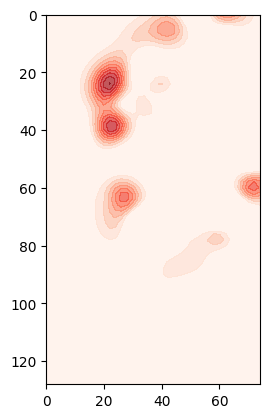

In [226]:
x0= np.argmax(np.max(D_gene, (1,2)))
i0 = np.argmin(np.abs(x_lin - x0))

plt.contourf(
        Zg[i0], Yg[i0], D_gene[i0],
        levels=10, cmap="Reds", 
#     vmin = D_gene.min(), vmax = D_gene.max(), 
    alpha=0.7
    )
plt.gca().invert_yaxis()
plt.gca().set_aspect("equal")

In [227]:
x0

np.int64(20)

In [117]:
N_grid =60

x_lin = np.linspace(x_min, x_max, N_grid)
y_lin = np.linspace(y_min, y_max, N_grid)
z_lin = np.linspace(z_min, z_max, N_grid)

# “indexing='ij'” ensures Xg[i,j,k]=x_lin[i], Yg[i,j,k]=y_lin[j], Zg[i,j,k]=z_lin[k].
Xg, Yg, Zg = np.meshgrid(x_lin, y_lin, z_lin, indexing="ij")

# Evaluate the RBF on the entire grid.
pts_x = Xg.ravel() 
pts_y = Yg.ravel()
pts_z = Zg.ravel()
gvals = rbf3d(pts_x, pts_y, pts_z)      # shape = (n^3,)
G = gvals.reshape((N_grid, N_grid, N_grid))            # Now G[i,j,k] = g(x_lin[i], y_lin[j], z_lin[k])

dG_dx, dG_dy, dG_dz = np.gradient(G, dx, dy, dz, edge_order=2)

Max |∇g| at x≈40.19 is ~ 2.48e+08


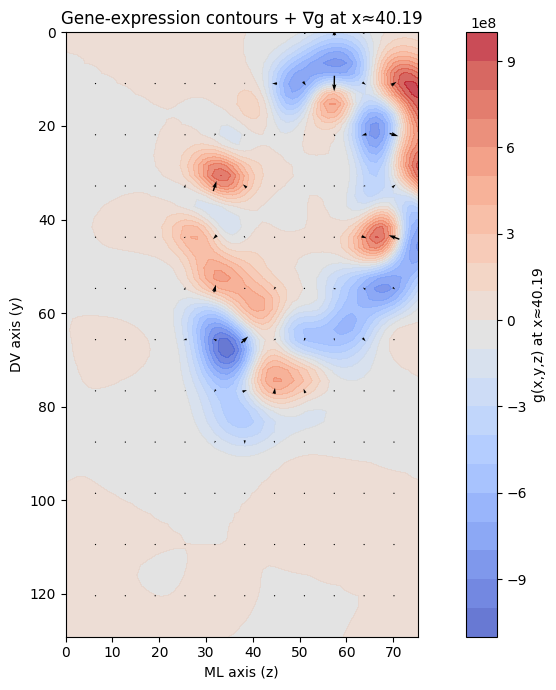

In [120]:

x0= np.argmax(np.max(dG_dx, (1,2)))
i0 = np.argmin(np.abs(x_lin - x0))

G_slice   = G[i0, :, :]     # shape (n,n); G_slice[j,k] = g(x0, y_lin[j], z_lin[k])
dGy_slice = dG_dy[i0, :, :] # ∂g/∂y at that slice, shape (n,n)
dGz_slice = dG_dz[i0, :, :] # ∂g/∂z at that slice, shape (n,n)

Y_slice = Yg[i0, :, :]      # shape (n,n): Y_slice[j,k] = y_lin[j]
Z_slice = Zg[i0, :, :]      # shape (n,n): Z_slice[j,k] = z_lin[k]


plt.figure(figsize=(10,7))
cf = plt.contourf(
    Z_slice,            # X‐axis = ML (z)
    Y_slice,            # Y‐axis = DV (y)
    G_slice,            # “height” = gene expression g(x0,y,z)
    levels=20,
    cmap="coolwarm",
    alpha=0.8
)
plt.colorbar(cf, label=f"g(x,y,z) at x≈{x_lin[i0]:.2f}")
plt.gca().set_aspect("equal", "box")

mag = np.sqrt(dGz_slice**2 + dGy_slice**2)
max_mag = mag.max()
print(f"Max |∇g| at x≈{x_lin[i0]:.2f} is ~ {max_mag:.2e}")

step = 5 
Q = plt.quiver(
     Z_slice[::step, ::step], 
    Y_slice[::step, ::step], 
    dGz_slice[::step, ::step], 
    dGy_slice[::step, ::step],
    color="black",
    pivot="mid",
    angles="xy",
    scale_units="xy",
    scale=max_mag * .3,   # adjust this factor to make arrows “just right”
    width=0.004
)

plt.xlabel("ML axis (z)")
plt.ylabel("DV axis (y)")
plt.gca().invert_yaxis()   # if you want the same “image‐style” y‐flipping as before
plt.title("Gene‐expression contours + ∇g at x≈{:.2f}".format(x_lin[i0]))
plt.tight_layout()
plt.show()


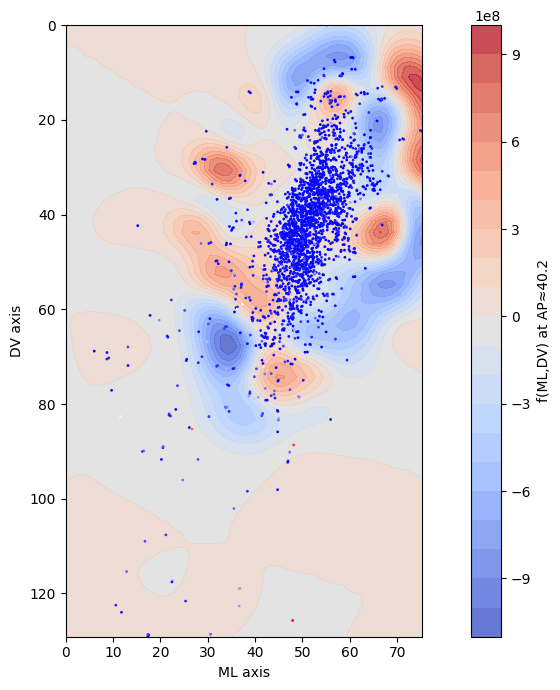

In [121]:
plt.figure(figsize=(10, 7))
cf = plt.contourf(
    Z_slice,            # X‐axis = ML (z)
    Y_slice,            # Y‐axis = DV (y)
    G_slice,            # “height” = gene expression g(x0,y,z)
    levels=20,
    cmap="coolwarm",
    alpha=0.8
)

plt.colorbar(label="f(ML,DV) at AP≈{:.1f}".format(x_lin[i0]))
plt.gca().set_aspect('equal')

sc = plt.scatter(coords[:, 2], coords[:, 1], c=expr, s=1,alpha = 1, cmap="bwr")

plt.ylabel("DV axis")
plt.xlabel("ML axis")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


# plot 2d marginal KDE

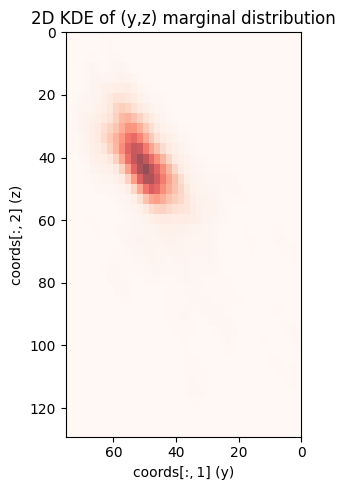

In [146]:
yz = coords[:, [2,1]]      # shape (4895, 2)
kde2d = gaussian_kde(yz.T)

# 3) build a grid over the (y,z) range
y_min, y_max = yz[:, 0].min(), yz[:, 0].max()
z_min, z_max = yz[:, 1].min(), yz[:, 1].max()

n_grid = 40
yy = np.linspace(y_min, y_max, n_grid)
zz = np.linspace(z_min, z_max, n_grid)
Yg, Zg = np.meshgrid(yy, zz)

# stack into shape (2, n_grid*n_grid) for evaluation
grid_points = np.vstack([Yg.ravel(), Zg.ravel()])  # (2, n_grid²)

# 4) compute log‐density on every (y,z) grid point
log_dens2d = kde2d.logpdf(grid_points)
dens2d = np.exp(log_dens2d).reshape(n_grid, n_grid)

# 5) contour‐plot or imshow the 2D density
plt.figure(figsize=(6, 5))

# fill with a colormap
plt.imshow(
    dens2d.T,
    origin="lower",
    aspect="equal",
    extent=[y_max, y_min, z_max, z_min],
    cmap="Reds",
    alpha=0.7,
)

plt.xlabel("coords[:, 1] (y)")
plt.ylabel("coords[:, 2] (z)")
plt.title("2D KDE of (y,z) marginal distribution")
plt.tight_layout()
plt.show()
